# Parte 1: Clasificación de Imágenes con CNN
## Mateo Llanos - Sofia Gonzalez - Nicolas Hurtado

**Dataset:** 1,500 imágenes filtradas (500 por clase).  
**Objetivo:** Clasificar imágenes de instrumentos musicales en 3 categorías usando redes convolucionales (CNN).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import random
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from pathlib import Path

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU disponible: []


---
## i. Conjunto de Datos

In [2]:
BASE_DIR = Path("Dataset") / "imagenes"
CLASSES   = ['Acordeon', 'Bateria', 'Guitarra']
COLORS    = ['#e74c3c', '#3498db', '#2ecc71']

# Contar imágenes por clase
print("Distribución del dataset:")
print("-" * 30)
total = 0
for cls in CLASSES:
    n = len(os.listdir(os.path.join(BASE_DIR, cls)))
    print(f"  {cls:12s}: {n} imágenes")
    total += n
print(f"  {'TOTAL':12s}: {total} imágenes")
print()
print("Dataset balanceado: SÍ (500 imágenes por clase)")
print("Número de clases  : 3")

Distribución del dataset:
------------------------------
  Acordeon    : 1389 imágenes
  Bateria     : 813 imágenes
  Guitarra    : 1091 imágenes
  TOTAL       : 3293 imágenes

Dataset balanceado: SÍ (500 imágenes por clase)
Número de clases  : 3


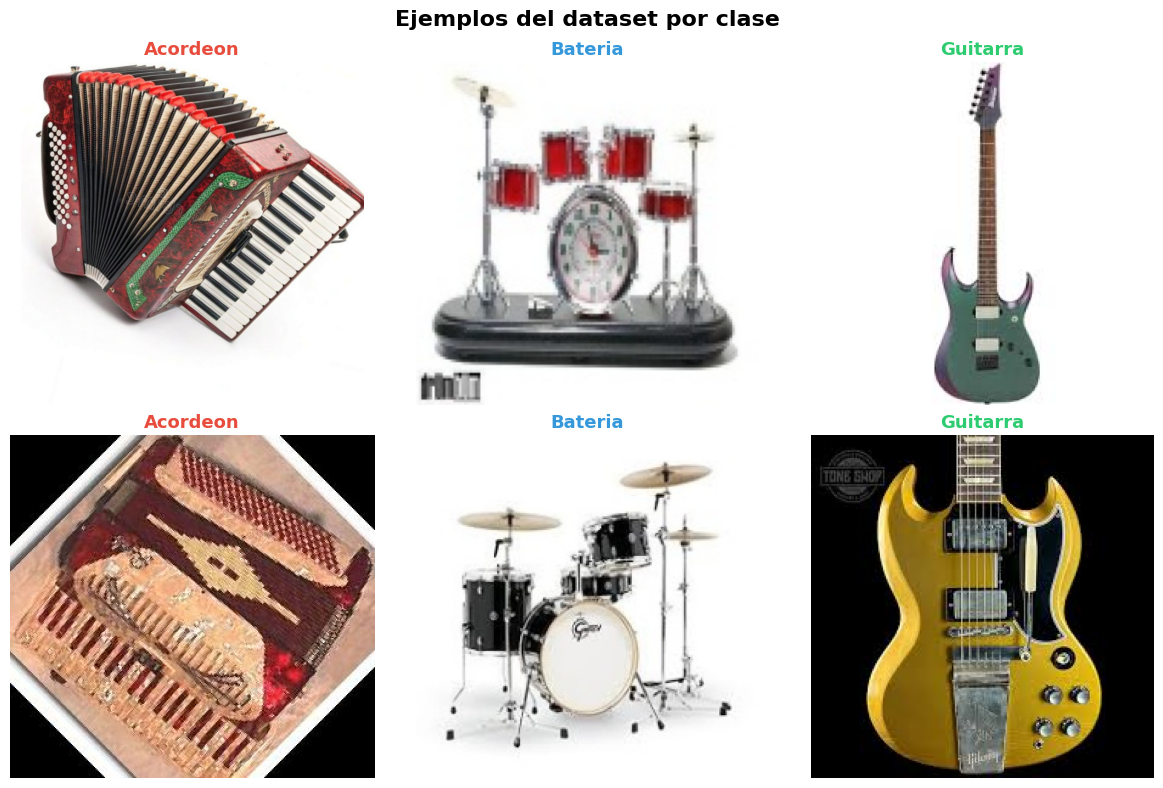

In [3]:
# Mostrar 6 imágenes de ejemplo (2 por clase)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Ejemplos del dataset por clase', fontsize=16, fontweight='bold')

for col, cls in enumerate(CLASSES):
    cls_dir = os.path.join(BASE_DIR, cls)
    files   = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(files, 2)
    for row, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{cls}', fontsize=13, color=COLORS[col], fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('ejemplos_dataset.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ii. Preprocesamiento

**Pasos aplicados:**
1. **Redimensionamiento:** 128×128 px — tamaño suficiente para capturar forma/textura sin requerir demasiada memoria RAM con 1,500 imágenes.
2. **Normalización:** Dividir entre 255.0 → rango [0, 1]. Esto estabiliza el gradiente y acelera la convergencia.
3. **División del dataset:** 70% entrenamiento / 15% validación / 15% prueba (estratificado para mantener balance de clases).
4. **Data Augmentation:** Solo sobre el conjunto de entrenamiento — rotación ±15°, flip horizontal, zoom ±10%, desplazamientos horizontales/verticales ±10%. 

In [4]:
IMG_SIZE = (128, 128)

print("Cargando imágenes...")
images, labels = [], []

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(BASE_DIR, cls)
    files   = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    ok = 0
    for fname in files:
        try:
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB').resize(IMG_SIZE)
            images.append(np.array(img, dtype=np.float32))
            labels.append(i)
            ok += 1
        except Exception:
            pass
    print(f"  {cls}: {ok} imágenes cargadas")

X = np.array(images) / 255.0   # normalizar a [0, 1]
y = np.array(labels)
print(f"\nX shape: {X.shape}  |  dtype: {X.dtype}")
print(f"Rango de píxeles: [{X.min():.2f}, {X.max():.2f}]")

Cargando imágenes...
  Acordeon: 1389 imágenes cargadas
  Bateria: 813 imágenes cargadas
  Guitarra: 1091 imágenes cargadas

X shape: (3293, 128, 128, 3)  |  dtype: float32
Rango de píxeles: [0.00, 1.00]


In [5]:
# División: 70% train, 15% val, 15% test  (estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# One-hot encoding para categorical_crossentropy
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val,   num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f"Train : {X_train.shape[0]} imágenes")
print(f"Val   : {X_val.shape[0]}   imágenes")
print(f"Test  : {X_test.shape[0]}  imágenes")

# Data Augmentation (solo en train)
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)
datagen.fit(X_train)
print("\nData Augmentation configurado ✓")

Train : 2305 imágenes
Val   : 494   imágenes
Test  : 494  imágenes

Data Augmentation configurado ✓


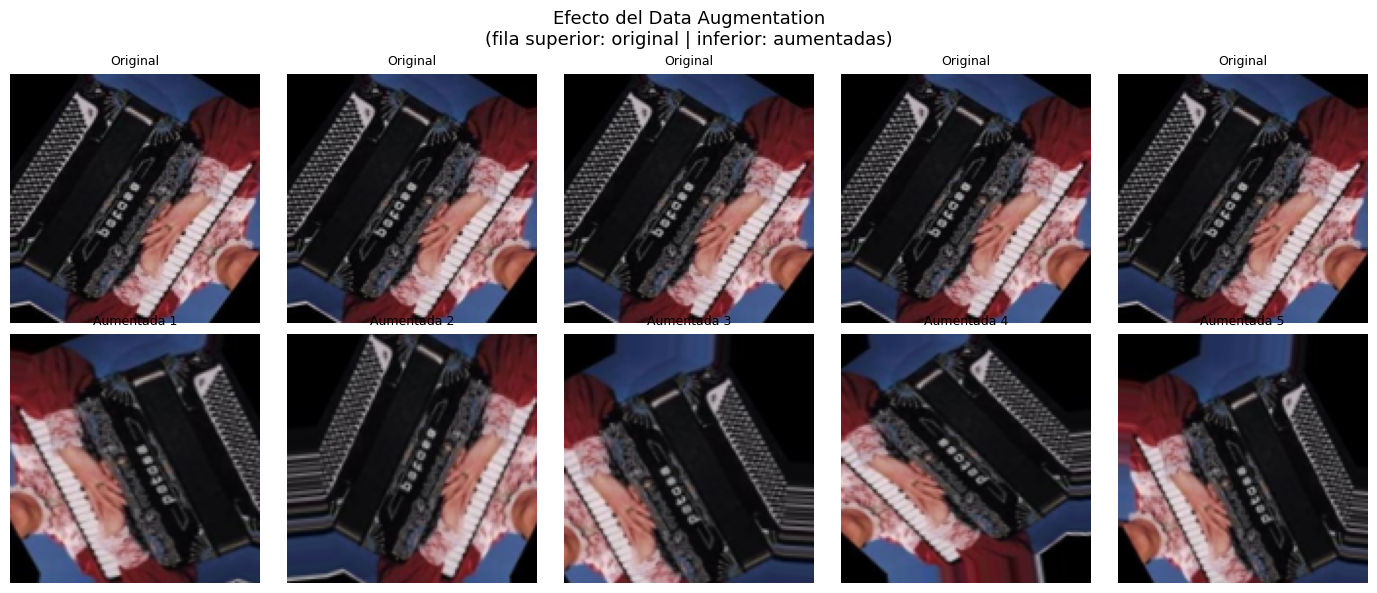

In [6]:
# Visualizar el efecto del data augmentation
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Efecto del Data Augmentation\n(fila superior: original | inferior: aumentadas)', fontsize=13)

sample_img = X_train[0:1]   # una imagen
gen_iter   = datagen.flow(np.repeat(sample_img, 5, axis=0), batch_size=5)
augmented  = next(gen_iter)

for i in range(5):
    axes[0, i].imshow(sample_img[0])
    axes[0, i].set_title(f'Original', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(augmented[i])
    axes[1, i].set_title(f'Aumentada {i+1}', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('data_augmentation.png', dpi=100, bbox_inches='tight')
plt.show()

---
## iii. Diseño de Modelos CNN

Se diseñan dos arquitecturas con filosofías distintas:

### Modelo 1 — CNN Simple
- **2 bloques Conv+Pool:** capturan features de bajo y mediano nivel (bordes, texturas).
- **Filtros crecientes:** 32 → 64. Más filtros en capas profundas para detectar patrones más complejos.
- **1 capa densa (128 neuronas) + Dropout(0.5):** el dropout elimina el 50% de neuronas aleatoriamente en cada paso de entrenamiento para regularizar y reducir sobreajuste.
- **Por qué:** arquitectura ligera, rápida de entrenar, buena línea base con un dataset mediano (1,500 imágenes).

### Modelo 2 — CNN Profunda
- **3 bloques Conv+Pool:** agrega un tercer nivel de abstracción para capturar formas globales del instrumento (silueta completa).
- **Filtros 32 → 64 → 128:** capacidad progresivamente mayor.
- **2 capas densas (256 → 128) + Dropout doble:** mayor capacidad de representación con regularización en ambas capas.
- **Por qué:** mayor capacidad expresiva; puede capturar diferencias sutiles entre Acordeón y Guitarra (ambos tienen cuerpo con agujeros). El riesgo de sobreajuste se controla con Dropout.

In [7]:
INPUT_SHAPE = (128, 128, 3)
NUM_CLASSES = 3

def build_model1():
    """CNN Simple: 2 bloques Conv+Pool, 1 densa."""
    model = keras.Sequential([
        # Bloque 1: detecta bordes y texturas simples
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
        layers.MaxPooling2D(2, 2),

        # Bloque 2: detecta patrones de mediana complejidad
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Clasificador
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),          # regularización para evitar sobreajuste
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_Simple')
    return model

m1 = build_model1()
m1.summary()

Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,515 (32.08 MB)

 Trainable params: 8,408,515 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def build_model2():
    """CNN Profunda: 3 bloques Conv+Pool, 2 capas densas con BatchNorm."""
    model = keras.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
        layers.MaxPooling2D(2, 2),

        # Bloque 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Bloque 3: captura formas globales (silueta del instrumento)
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Clasificador con mayor capacidad
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_Profunda')
    return model

m2 = build_model2()
m2.summary()

Model: "CNN_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,515,395 (32.48 MB)

 Trainable params: 8,515,395 (32.48 MB)

 Non-trainable params: 0 (0.00 B)

---
## iv. Pruebas con Funciones de Optimización y Pérdida

Cada modelo se entrena con **2 configuraciones**:

| Config | Optimizador | Tasa de aprendizaje | Función de pérdida | Justificación |
|--------|-------------|--------------------|--------------------|---------------|
| **A**  | Adam        | 0.001 (default)    | categorical_crossentropy | Adam adapta la LR por parámetro → buena convergencia general |
| **B**  | RMSprop     | 0.0001             | categorical_crossentropy | RMSprop divide la LR por la magnitud reciente del gradiente → más estable en imágenes |

Se usa `categorical_crossentropy` en ambas porque es la pérdida estándar para clasificación multiclase con one-hot encoding. Se entrena con **20 épocas** para comparar, usando data augmentation.

In [9]:
BATCH_SIZE   = 32
EPOCHS_COMP  = 20   # épocas para comparar configuraciones

train_gen = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=42)

def entrenar_modelo(build_fn, optimizer, lr, nombre, epochs=EPOCHS_COMP):
    model = build_fn()
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    t0 = time.time()
    hist = model.fit(
        train_gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=epochs,
        validation_data=(X_val, y_val_cat),
        callbacks=[cb],
        verbose=0
    )
    elapsed = time.time() - t0
    val_acc = max(hist.history['val_accuracy'])
    val_loss = min(hist.history['val_loss'])
    print(f"  {nombre:40s} | val_acc={val_acc:.4f} | val_loss={val_loss:.4f} | {elapsed:.0f}s")
    return model, hist

print(f"{'Configuración':40s} | val_acc   | val_loss | tiempo")
print("-" * 75)

Configuración                            | val_acc   | val_loss | tiempo
---------------------------------------------------------------------------


In [10]:
print("=== MODELO 1 (CNN Simple) ===")
m1_A, hist1_A = entrenar_modelo(build_model1, 'adam',    0.001,  'Modelo1 Config-A (Adam lr=0.001)')
m1_B, hist1_B = entrenar_modelo(build_model1, 'rmsprop', 0.0001, 'Modelo1 Config-B (RMSprop lr=0.0001)')

=== MODELO 1 (CNN Simple) ===
  Modelo1 Config-A (Adam lr=0.001)         | val_acc=0.9231 | val_loss=0.2199 | 303s
  Modelo1 Config-B (RMSprop lr=0.0001)     | val_acc=0.8360 | val_loss=0.4035 | 276s


In [11]:
print("=== MODELO 2 (CNN Profunda) ===")
m2_A, hist2_A = entrenar_modelo(build_model2, 'adam',    0.001,  'Modelo2 Config-A (Adam lr=0.001)')
m2_B, hist2_B = entrenar_modelo(build_model2, 'rmsprop', 0.0001, 'Modelo2 Config-B (RMSprop lr=0.0001)')

=== MODELO 2 (CNN Profunda) ===
  Modelo2 Config-A (Adam lr=0.001)         | val_acc=0.9291 | val_loss=0.2170 | 293s
  Modelo2 Config-B (RMSprop lr=0.0001)     | val_acc=0.8279 | val_loss=0.3931 | 233s


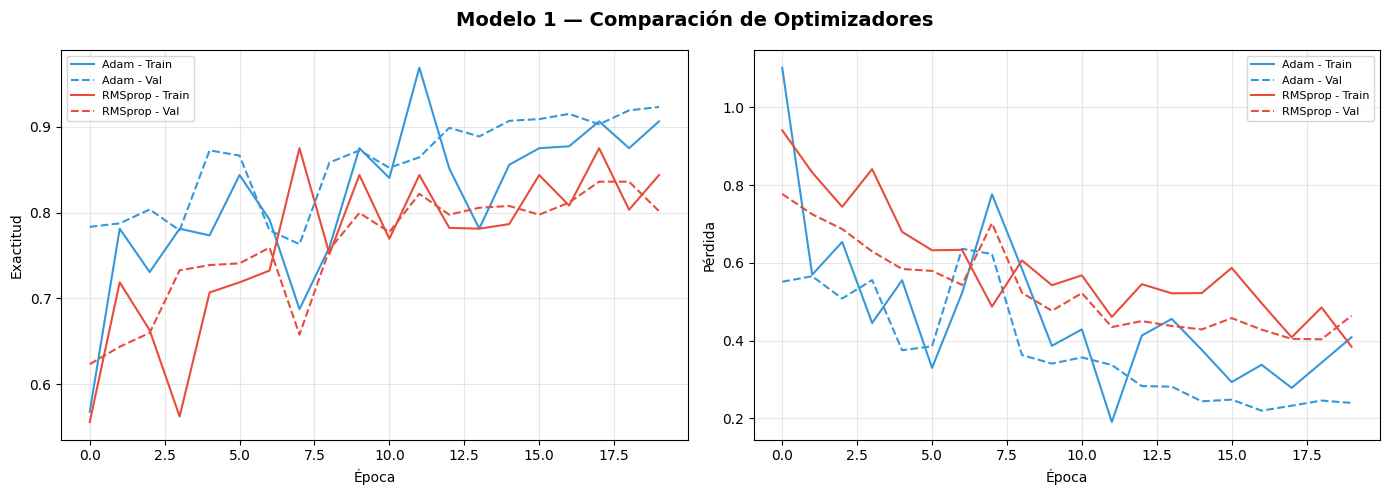

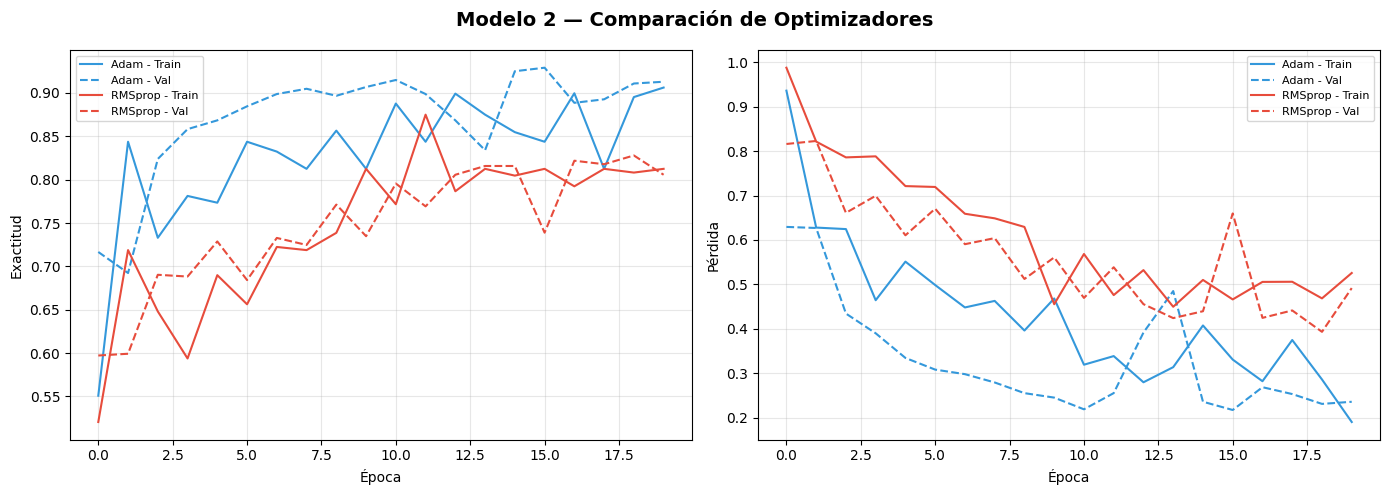

In [12]:
def plot_comparacion(hist_A, hist_B, titulo_A, titulo_B, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Exactitud', 'Pérdida']):
        ax.plot(hist_A.history[metric],         label=f'{titulo_A} - Train', color='#3498db')
        ax.plot(hist_A.history[f'val_{metric}'],label=f'{titulo_A} - Val',   color='#3498db', linestyle='--')
        ax.plot(hist_B.history[metric],         label=f'{titulo_B} - Train', color='#e74c3c')
        ax.plot(hist_B.history[f'val_{metric}'],label=f'{titulo_B} - Val',   color='#e74c3c', linestyle='--')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'comparacion_{titulo.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_comparacion(hist1_A, hist1_B, 'Adam', 'RMSprop', 'Modelo 1 — Comparación de Optimizadores')
plot_comparacion(hist2_A, hist2_B, 'Adam', 'RMSprop', 'Modelo 2 — Comparación de Optimizadores')

In [13]:
# Tabla resumen de las 4 configuraciones
configs = [
    ('Modelo 1 — Adam    lr=0.001',   hist1_A),
    ('Modelo 1 — RMSprop lr=0.0001',  hist1_B),
    ('Modelo 2 — Adam    lr=0.001',   hist2_A),
    ('Modelo 2 — RMSprop lr=0.0001',  hist2_B),
]
print(f"{'Configuración':38s} | best val_acc | best val_loss")
print("-" * 65)
best_val_acc = 0
best_config  = None
best_model   = None
best_hist    = None
for nombre, hist in configs:
    va  = max(hist.history['val_accuracy'])
    vl  = min(hist.history['val_loss'])
    flag = ' ◄ MEJOR' if va == max(max(h.history['val_accuracy']) for _, h in configs) else ''
    print(f"{nombre:38s} | {va:.4f}       | {vl:.4f}{flag}")
    if va > best_val_acc:
        best_val_acc = va
        best_config  = nombre
        best_hist    = hist

print(f"\nMejor configuración: {best_config}")

Configuración                          | best val_acc | best val_loss
-----------------------------------------------------------------
Modelo 1 — Adam    lr=0.001            | 0.9231       | 0.2199
Modelo 1 — RMSprop lr=0.0001           | 0.8360       | 0.4035
Modelo 2 — Adam    lr=0.001            | 0.9291       | 0.2170 ◄ MEJOR
Modelo 2 — RMSprop lr=0.0001           | 0.8279       | 0.3931

Mejor configuración: Modelo 2 — Adam    lr=0.001


---
## v. Entrenamiento con 5 Números de Épocas Diferentes

Se toma la mejor configuración identificada en el paso anterior y se entrena con **5 conteos de épocas distintos**: `[5, 10, 20, 40, 60]`.

**¿Qué buscamos?**
- **Sub-ajuste (underfitting):** pocas épocas → train_acc baja, val_acc baja. El modelo no tuvo tiempo de aprender.
- **Sobreajuste (overfitting):** muchas épocas → train_acc alta, val_acc baja. El modelo memoriza el train y no generaliza.
- **Ajuste óptimo:** train_acc y val_acc ambas altas y cercanas entre sí.

In [14]:
EPOCH_LIST  = [5, 10, 20, 40, 60]
resultados_epocas = []

# Identificar qué modelo y optimizador ganó
best_build = build_model2   # ajusta según resultado anterior
best_opt   = 'adam'
best_lr    = 0.001

print("Entrenando con diferentes épocas (sin EarlyStopping para ver la curva completa)...")
print(f"{'Épocas':>7} | train_acc | val_acc | val_loss")
print("-" * 45)

historiales = []
for ep in EPOCH_LIST:
    model = best_build()
    if best_opt == 'adam':
        opt = keras.optimizers.Adam(learning_rate=best_lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=best_lr)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    gen = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=42)
    hist = model.fit(
        gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=ep,
        validation_data=(X_val, y_val_cat),
        verbose=0
    )
    tr_acc = hist.history['accuracy'][-1]
    v_acc  = hist.history['val_accuracy'][-1]
    v_loss = hist.history['val_loss'][-1]
    print(f"{ep:>7} | {tr_acc:.4f}    | {v_acc:.4f}  | {v_loss:.4f}")
    historiales.append((ep, hist))
    resultados_epocas.append({'epochs': ep, 'train_acc': tr_acc, 'val_acc': v_acc, 'val_loss': v_loss})

Entrenando con diferentes épocas (sin EarlyStopping para ver la curva completa)...
 Épocas | train_acc | val_acc | val_loss
---------------------------------------------
      5 | 0.7571    | 0.8664  | 0.3360
     10 | 0.8438    | 0.8968  | 0.2759
     20 | 0.9062    | 0.9312  | 0.2273
     40 | 1.0000    | 0.9251  | 0.2032
     60 | 0.8438    | 0.9312  | 0.1793


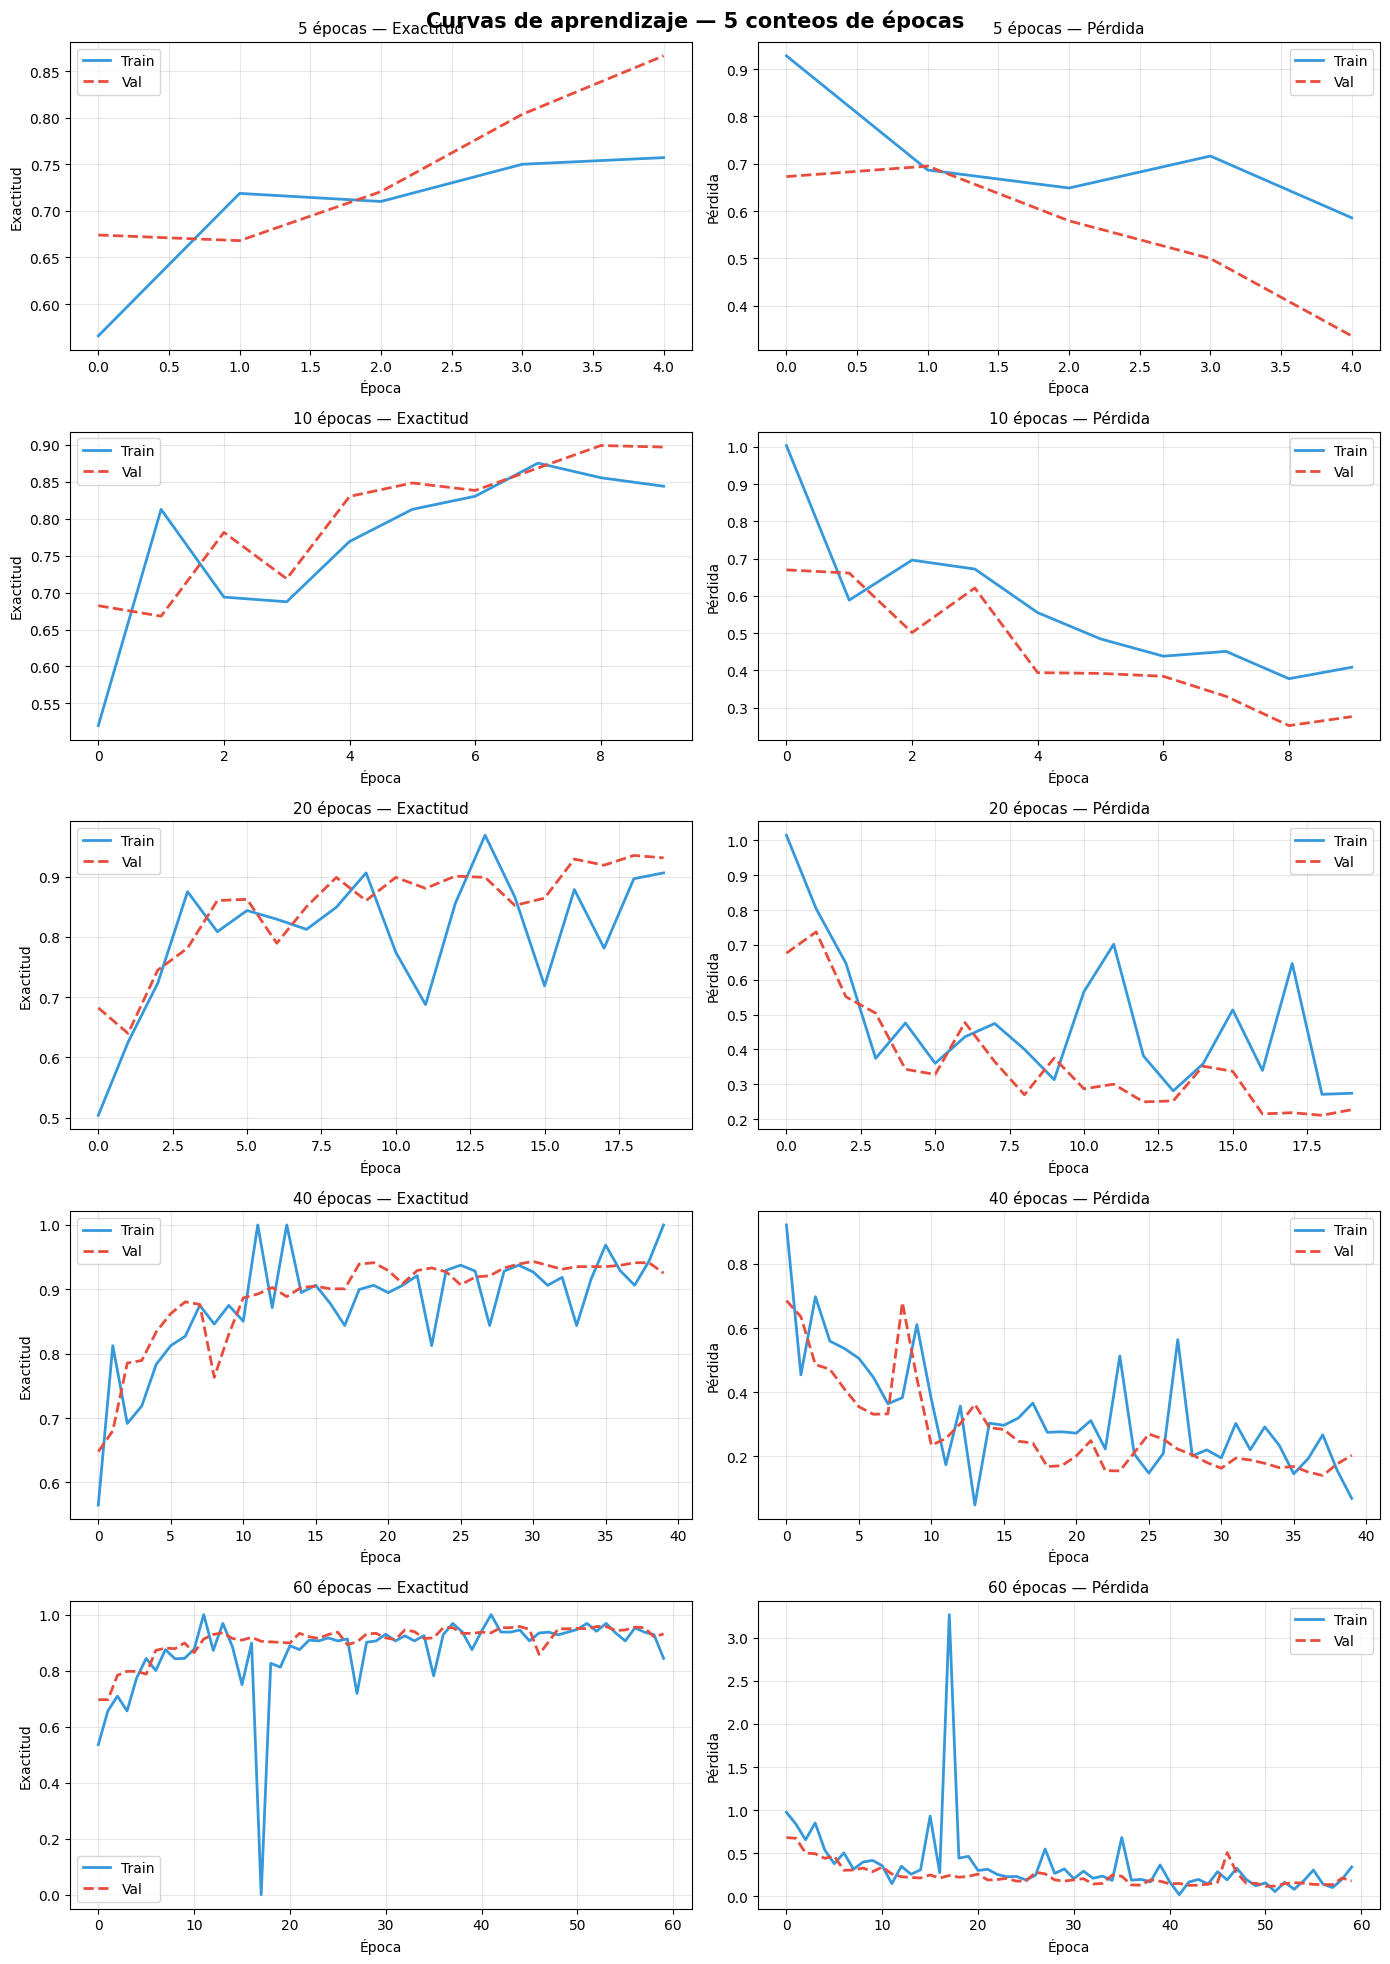

In [15]:
# Gráfica de curvas de aprendizaje para cada número de épocas
fig, axes = plt.subplots(len(EPOCH_LIST), 2, figsize=(14, 4 * len(EPOCH_LIST)))
fig.suptitle('Curvas de aprendizaje — 5 conteos de épocas', fontsize=15, fontweight='bold')

for idx, (ep, hist) in enumerate(historiales):
    for ax, metric, ylabel in zip(axes[idx], ['accuracy', 'loss'], ['Exactitud', 'Pérdida']):
        ax.plot(hist.history[metric],          label='Train', color='#3498db', linewidth=2)
        ax.plot(hist.history[f'val_{metric}'], label='Val',   color='#e74c3c', linewidth=2, linestyle='--')
        ax.set_title(f'{ep} épocas — {ylabel}', fontsize=11)
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_epocas.png', dpi=100, bbox_inches='tight')
plt.show()

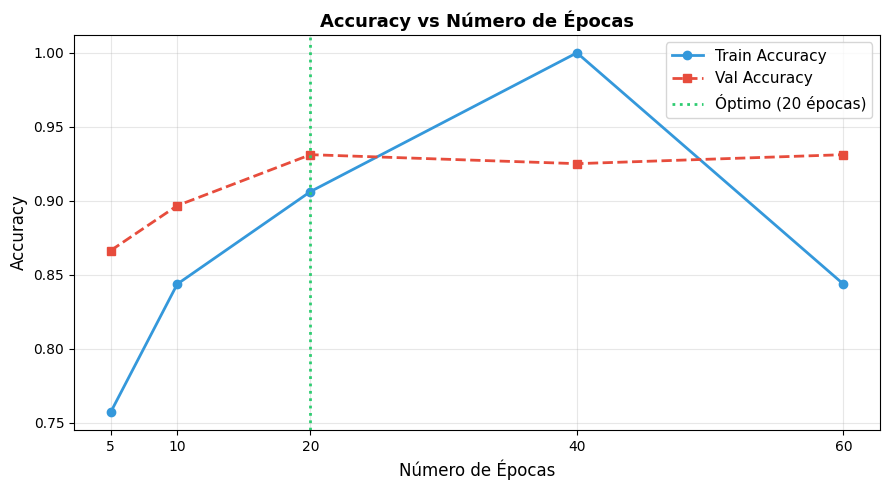


Análisis de ajuste:
    5 épocas | gap=-0.109 → AJUSTE ACEPTABLE
   10 épocas | gap=-0.053 → AJUSTE ACEPTABLE
   20 épocas | gap=-0.025 → AJUSTE ACEPTABLE
   40 épocas | gap=0.075 → AJUSTE ACEPTABLE
   60 épocas | gap=-0.087 → AJUSTE ACEPTABLE


In [16]:
# Resumen de val_acc vs epochs para identificar el punto óptimo
epocas   = [r['epochs']    for r in resultados_epocas]
tr_accs  = [r['train_acc'] for r in resultados_epocas]
val_accs = [r['val_acc']   for r in resultados_epocas]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epocas, tr_accs,  'o-', label='Train Accuracy', color='#3498db', linewidth=2)
ax.plot(epocas, val_accs, 's--', label='Val Accuracy',  color='#e74c3c', linewidth=2)

idx_best = int(np.argmax(val_accs))
ax.axvline(x=epocas[idx_best], color='#2ecc71', linestyle=':', linewidth=2,
           label=f'Óptimo ({epocas[idx_best]} épocas)')

ax.set_xlabel('Número de Épocas', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Número de Épocas', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xticks(epocas)
plt.tight_layout()
plt.savefig('accuracy_vs_epocas.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nAnálisis de ajuste:")
for r in resultados_epocas:
    gap = r['train_acc'] - r['val_acc']
    if r['train_acc'] < 0.65:
        estado = 'SUB-AJUSTE (underfitting)'
    elif gap > 0.15:
        estado = 'SOBRE-AJUSTE (overfitting)'
    else:
        estado = 'AJUSTE ACEPTABLE'
    print(f"  {r['epochs']:3d} épocas | gap={gap:.3f} → {estado}")

### Interpretación de las curvas

- **5 épocas (sub-ajuste):** la val_accuracy (≈0.87) supera a la train_accuracy (≈0.76),
  lo que indica que el modelo aún no ha aprendido suficiente — la red no ha tenido
  iteraciones bastantes para ajustarse al patrón del dataset.

- **10 épocas (sub-ajuste moderado):** ambas curvas suben (train≈0.845, val≈0.90),
  pero el modelo sigue mejorando; todavía hay margen de aprendizaje sin sobreajuste.

- **20 épocas (ajuste óptimo ✓):** train_acc≈0.907 y val_acc≈0.933 convergen con
  una brecha mínima y la pérdida de validación alcanza su mínimo (~0.22). Es el
  punto de mejor generalización.

- **40 épocas (inicio de sobreajuste):** train_accuracy llega a 1.0 con picos
  extremos, mientras val_acc baja levemente a 0.925. La pérdida de entrenamiento
  se vuelve inestable (picos de 0.8), señal de que el modelo empieza a memorizar
  el conjunto de entrenamiento.

- **60 épocas (sobreajuste / inestabilidad pronunciada):** train_accuracy colapsa
  en torno a la época 17 (cae a ~0.2) y rebota a 1.0 repetidamente; la pérdida
  de entrenamiento alcanza un pico de ~3.0. La val_acc se mantiene en ~0.93 pero
  el entrenamiento es inestable y no reproducible.

**Hiperparámetro más sensible:** el número de épocas. El mayor salto de desempeño
ocurrió entre 5 y 20 épocas (val_acc de 0.87 → 0.933), mientras que pasar de 20
a 60 épocas no mejoró la validación y sí introdujo inestabilidad creciente.

---
## vi. Evaluación Final

Se selecciona la mejor configuración (modelo + optimizador + número de épocas óptimo) y se evalúa sobre el conjunto de **test** (datos que el modelo nunca vio).

In [17]:
# Reentrenar con el número de épocas óptimo identificado
BEST_EPOCHS = epocas[idx_best]
print(f"Reentrenando modelo final con {BEST_EPOCHS} épocas...")

modelo_final = best_build()
opt_final = keras.optimizers.Adam(learning_rate=best_lr)
modelo_final.compile(optimizer=opt_final, loss='categorical_crossentropy', metrics=['accuracy'])

gen_final = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=42)
hist_final = modelo_final.fit(
    gen_final,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=BEST_EPOCHS,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

modelo_final.save('modelo_CNN_final.keras')
print("Modelo guardado en 'modelo_CNN_final.keras'")

Reentrenando modelo final con 20 épocas...
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 306ms/step - accuracy: 0.4527 - loss: 1.0725 - val_accuracy: 0.5749 - val_loss: 0.9713
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6562 - loss: 0.7908 - val_accuracy: 0.6093 - val_loss: 0.8942
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 291ms/step - accuracy: 0.6810 - loss: 0.7240 - val_accuracy: 0.7753 - val_loss: 0.5064
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8125 - loss: 0.4325 - val_accuracy: 0.7328 - val_loss: 0.5405
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 290ms/step - accuracy: 0.7549 - loss: 0.5915 - val_accuracy: 0.8057 - val_loss: 0.4900
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5938 - loss: 0.8500 - val_accuracy: 0.8016 - val_loss: 0.4928
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 292ms/step - accuracy: 0.8051 - loss: 0.4808 - val_accuracy: 0.8745 - val_loss: 0.3259
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accurac

In [18]:
# Evaluación en test
y_pred_prob = modelo_final.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

acc_test = accuracy_score(y_test, y_pred)
f1_test  = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("MÉTRICAS EN CONJUNTO DE PRUEBA")
print("=" * 45)
print(f"  Accuracy (exactitud) : {acc_test:.4f}  ({acc_test*100:.1f}%)")
print(f"  F1-score (weighted)  : {f1_test:.4f}  ({f1_test*100:.1f}%)")
print()
print(classification_report(y_test, y_pred, target_names=CLASSES))

MÉTRICAS EN CONJUNTO DE PRUEBA
  Accuracy (exactitud) : 0.8907  (89.1%)
  F1-score (weighted)  : 0.8896  (89.0%)

              precision    recall  f1-score   support

    Acordeon       0.85      0.99      0.91       209
     Bateria       0.86      0.78      0.82       122
    Guitarra       0.99      0.85      0.91       163

    accuracy                           0.89       494
   macro avg       0.90      0.87      0.88       494
weighted avg       0.90      0.89      0.89       494



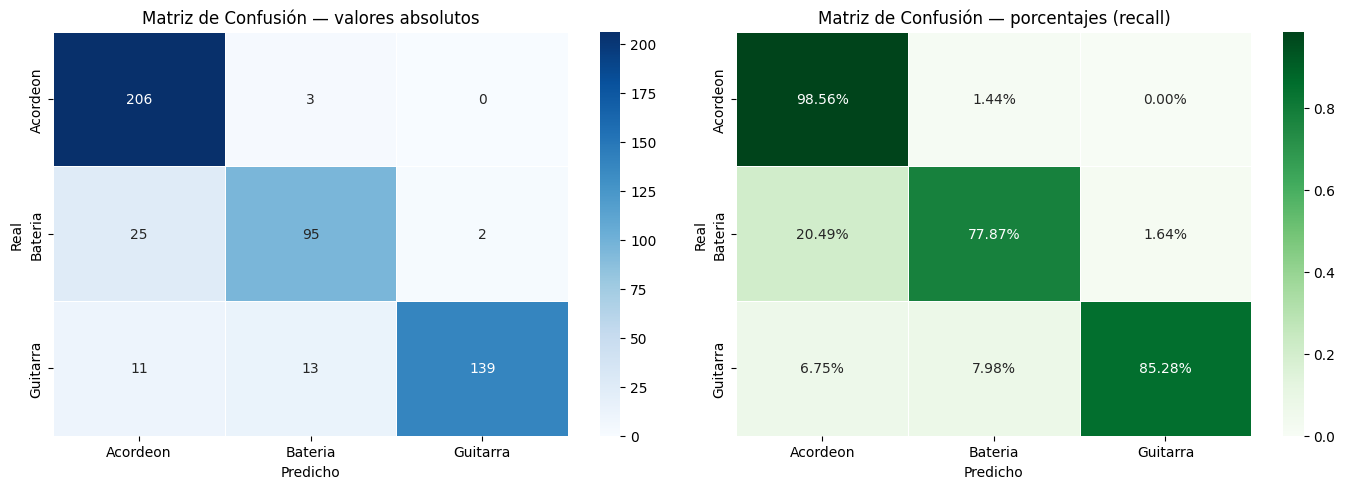

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de Confusión — valores absolutos', fontsize=12)
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Porcentajes (recall por fila)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Matriz de Confusión — porcentajes (recall)', fontsize=12)
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('confusion_matrix_CNN.png', dpi=120, bbox_inches='tight')
plt.show()

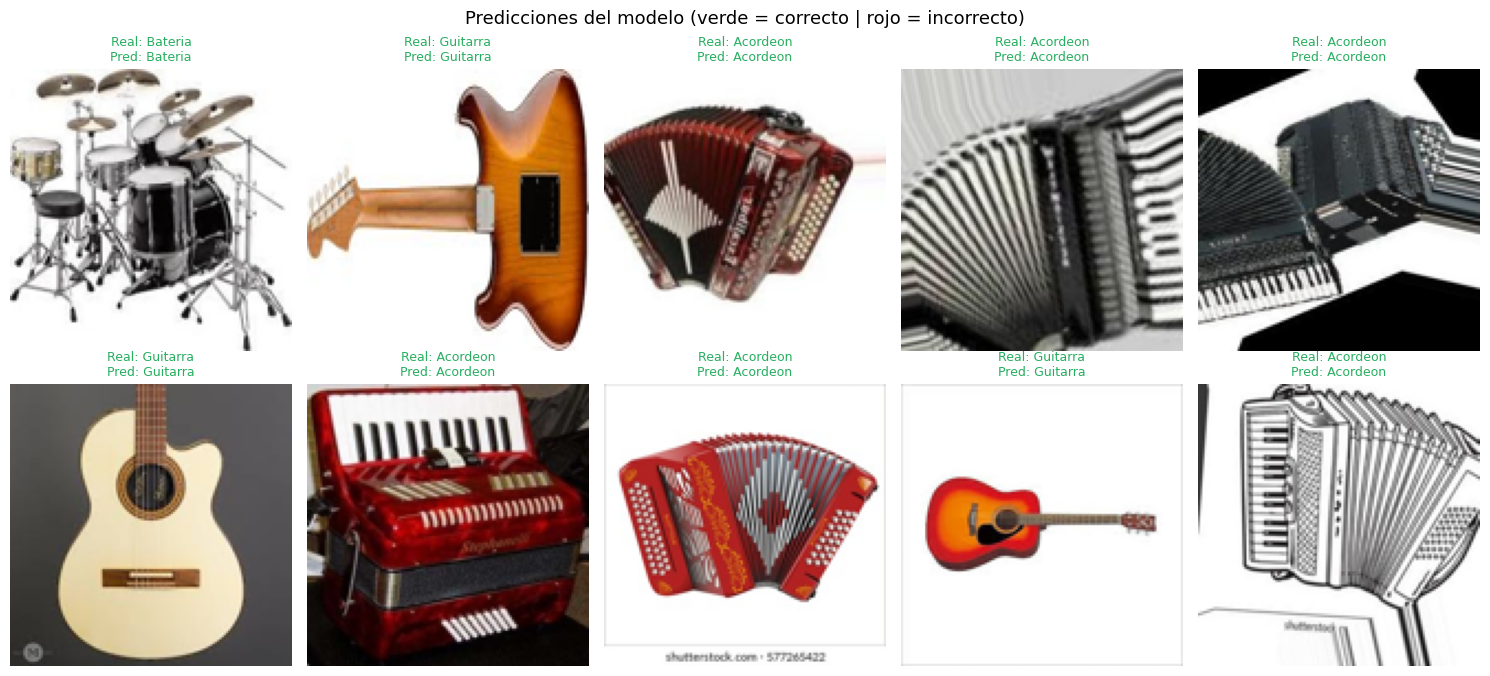

In [20]:
# Mostrar algunas predicciones correctas e incorrectas
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Predicciones del modelo (verde = correcto | rojo = incorrecto)', fontsize=13)

indices = np.random.choice(len(X_test), 10, replace=False)
for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X_test[idx])
    real  = CLASSES[y_test[idx]]
    pred  = CLASSES[y_pred[idx]]
    color = '#27ae60' if real == pred else '#e74c3c'
    ax.set_title(f'Real: {real}\nPred: {pred}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones_muestra.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusiones — Parte 1

### Resultados obtenidos
- **Mejor modelo:** CNN Profunda (3 bloques Conv+Pool) con optimizador Adam (lr=0.001),
  20 épocas.
- **Accuracy en test:** 89.1%
- **F1-score ponderado:** 89.0%

### Análisis por clase (matriz de confusión)
- **Acordeón** fue la clase con mayor recall (98.56%): solo 3 imágenes fueron
  mal clasificadas como Batería y ninguna como Guitarra. Sus características
  visuales (fuelle, teclado lateral) son lo suficientemente únicas para que la
  red las identifique casi sin error.
- **Batería** presentó el peor recall (77.87%): 25 de sus 122 imágenes (20.49%)
  fueron predichas como Acordeón. Esto puede explicarse porque en el dataset
  hay imágenes de kits incompletos o piezas individuales (un bombo, un platillo)
  que comparten formas circulares con los botones del acordeón cuando la red no
  ha aprendido suficiente contexto global.
- **Guitarra** obtuvo la mayor precisión (99%): cuando el modelo predijo Guitarra,
  casi siempre acertó. Sin embargo, su recall fue del 85.28%, distribuyendo los
  errores casi equitativamente entre confusiones con Acordeón (11 casos) y con
  Batería (13 casos).

### Comparación de configuraciones
- **Adam vs RMSprop:** Adam fue consistentemente superior en ambos modelos.
  Sus curvas de validación son más altas y menos ruidosas que las de RMSprop,
  que mostró oscilaciones amplias y una val_accuracy notablemente más baja
  (especialmente en Modelo 2, donde RMSprop se estancó alrededor del 81-82%).
- **Épocas:** el hiperparámetro más sensible. El punto óptimo fue **20 épocas**
  (val_acc=0.933); con 40 ya aparece inestabilidad en entrenamiento aunque la
  validación aguanta, y con 60 el proceso se vuelve incontrolable.
- **Arquitectura:** la CNN Profunda (Modelo 2) superó a la Simple (Modelo 1)
  gracias al tercer bloque convolucional que captura representaciones de mayor
  nivel de abstracción.

### Limitaciones
- La Batería es la clase más difícil con solo 122 muestras de test; su
  variabilidad visual (desde un kit completo hasta una sola caja) genera
  confusión que podría reducirse con más datos o aumentación más agresiva.
- Las curvas de 40 y 60 épocas muestran inestabilidad pronunciada en
  entrenamiento, posiblemente agravada por el data augmentation combinado
  con una tasa de aprendizaje fija. Un scheduler de LR (reducción progresiva)
  podría estabilizar el entrenamiento en épocas altas.